<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%204/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install category_encoders
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import category_encoders as ce

In [ ]:
df_vitals = pd.read_csv("OmniCare_Clinical_Vitals.csv")
df = pd.read_csv("OmniCare_Telemetry_Data.csv")

Low income status  -> High Deductible Plan            
Unobserved ->  Inpatient Admission

The omitted confounder is the patients income. Patients with a low income may have no choice but to pick a high-deductible insurance plans. Low income individuals are also more likely to have worse health in general due to their lack of access to general care. This leads to a biased, mathematically contaminated predictive weight by assuming correlation equals causation.

In [ ]:
features = df_vitals[[
    "Weight_kg",
    "Height_cm",
    "BMI",
    "Systolic_BP",
    "Diastolic_BP"
]].dropna()

X = features.copy()
X["const"] = 1

vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)

       Variable          VIF
0     Weight_kg    57.428058
1     Height_cm    28.419446
2           BMI    16.981232
3   Systolic_BP     4.219406
4  Diastolic_BP     4.219820
5         const  3369.565806


In [ ]:
features_clean = df_vitals[[
    "Weight_kg",
    "Height_cm",
    "Systolic_BP",
    "Diastolic_BP"
]].dropna()

X_clean = features_clean.copy()
X_clean["const"] = 1

vif_clean = pd.DataFrame()
vif_clean["Variable"] = X_clean.columns
vif_clean["VIF"] = [variance_inflation_factor(X_clean.values, i) for i in range(X_clean.shape[1])]

print(vif_clean)

       Variable         VIF
0     Weight_kg    3.763969
1     Height_cm    3.763812
2   Systolic_BP    4.219406
3  Diastolic_BP    4.219820
4         const  321.090128


The missing data is missing not at random. The probability of missing heart rate data depends on unobserved patient income, since low-income patients may avoid transmitting data due to data-plan costs. Mean imputation would destroy the dataset's integrity because it would just fill empty observations with an average, causing a bias



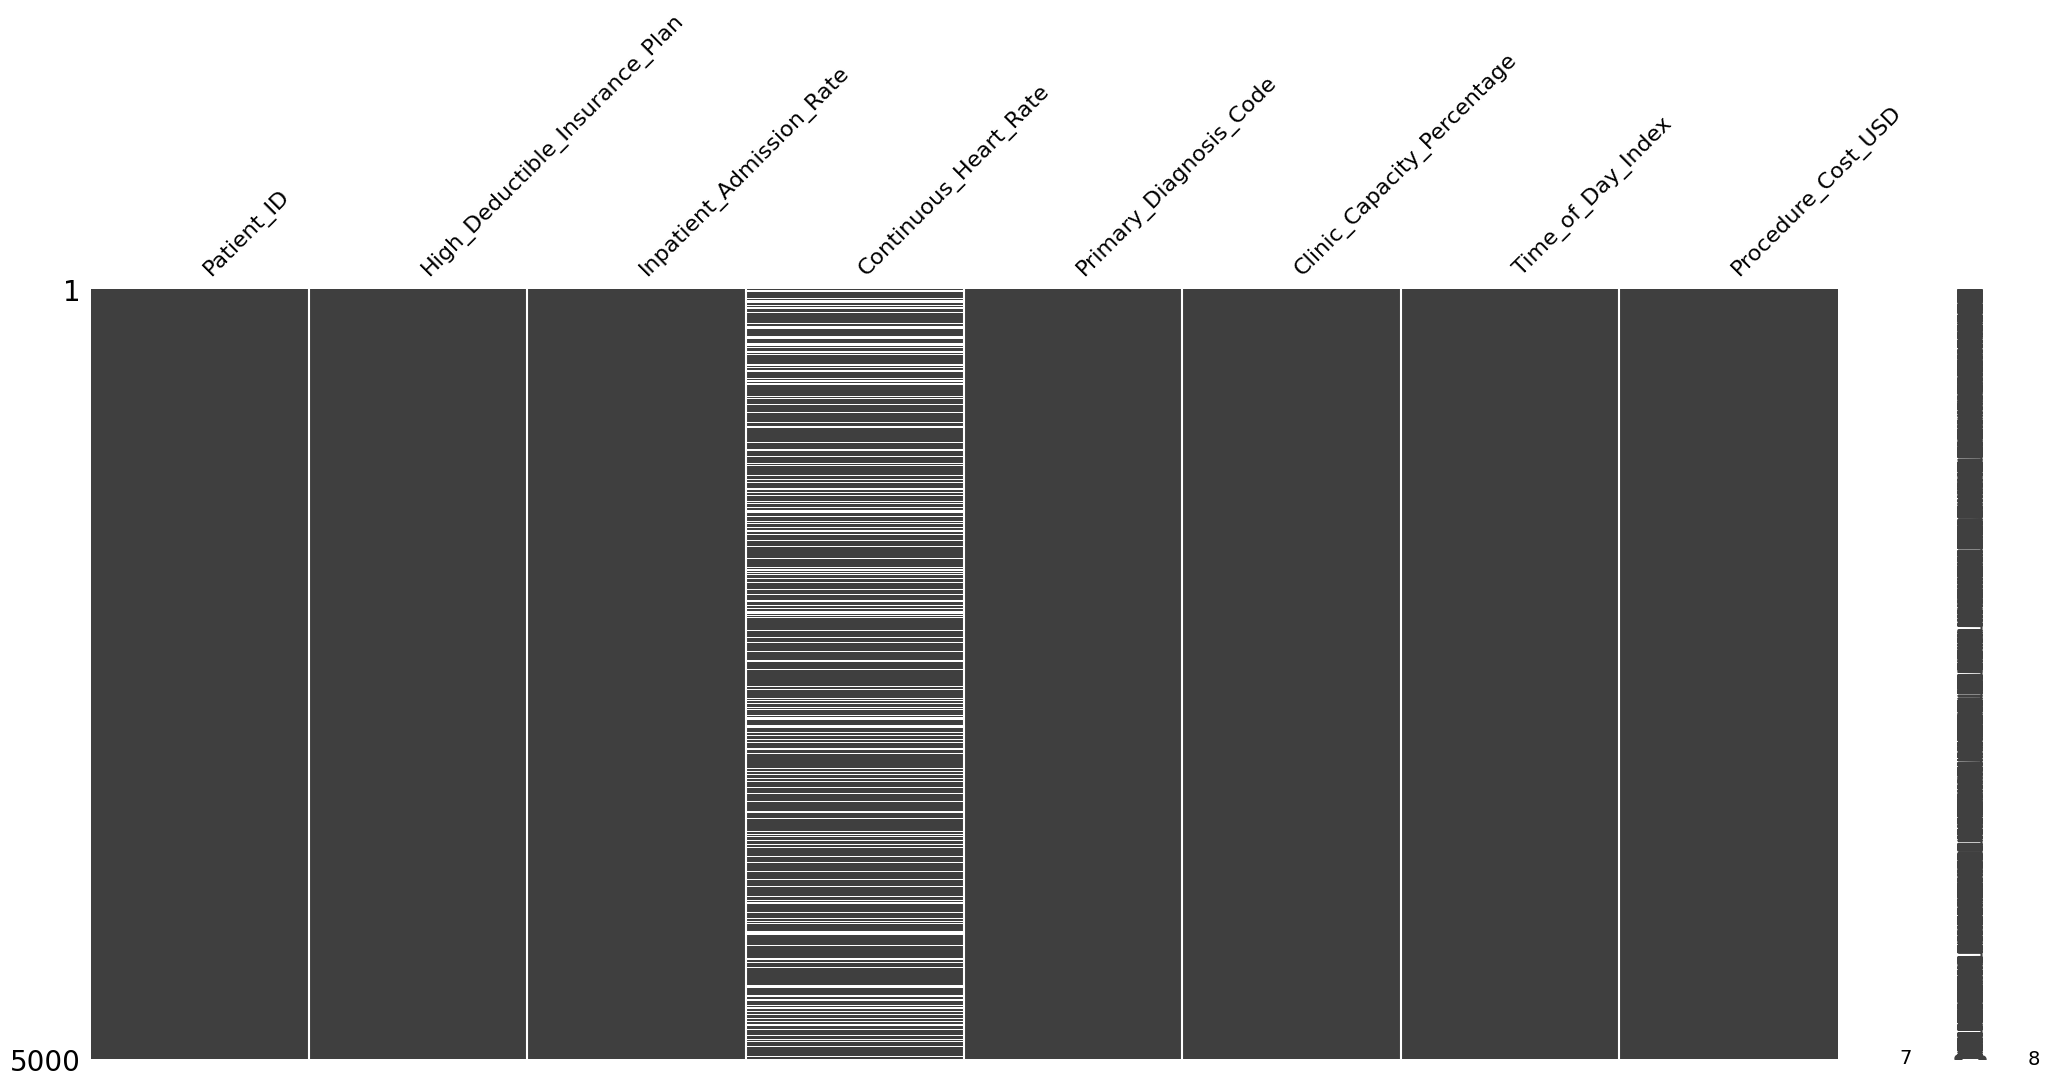

In [ ]:
msno.matrix(df)
plt.show()

The inclusion of a constant intercept term alongside these 850 comprehensive dummy columns creates a singular design matrix and mathematically destroys the Ordinary Least Squares estimator because it causes multicollinearity.

In [ ]:
encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])

df["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    df["Primary_Diagnosis_Code"],
    df["Procedure_Cost_USD"]
)

print(df[["Target_Encoded_Diagnosis"]].head())

   Target_Encoded_Diagnosis
0               1707.697108
1               1792.303198
2               1730.334968
3               1725.060944
4               1801.821085


In [ ]:
df_model = df.copy()
df_model = df_model.join(features_clean, how="inner")

df_model = df_model[[
    "Procedure_Cost_USD",
    "Target_Encoded_Diagnosis",
    "Clinic_Capacity_Percentage",
    "Time_of_Day_Index",
    "Weight_kg",
    "Height_cm",
    "Systolic_BP",
    "Diastolic_BP"
]].dropna()

In [ ]:
model = smf.ols(
    "Procedure_Cost_USD ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + Time_of_Day_Index + Weight_kg + Height_cm + Systolic_BP + Diastolic_BP",
    data=df_model
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        01:37:23   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [ ]:
pred = model.fittedvalues
actual = df_model["Procedure_Cost_USD"]

rmse_val = rmse(actual, pred)
print("Root Mean Squared Error:", rmse_val)

Root Mean Squared Error: 334.80215211463116


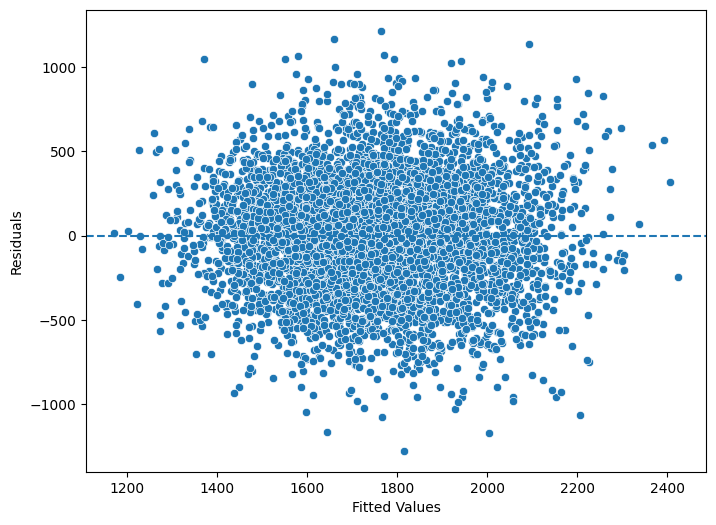

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

Act as an applied econometrician working in Python. I have already estimated an OLS regression in Google Colab using statsmodels, and my fitted regression object is stored as model. Write clean, minimal Python code that performs White’s Lagrange Multiplier Test for Heteroscedasticity using statsmodels.stats.diagnostic.het_white on my exact OLS model output.

P — Purpose:
Test whether the residuals from my fitted OLS model violate the homoscedasticity assumption.

R — Role:
You are an expert econometric coding assistant writing code for a student using pandas, statsmodels, and Google Colab.

I — Input:
My fitted OLS model object is named model. Use model.resid for residuals and model.model.exog for the matrix of explanatory variables.

M — Method:
Import het_white from statsmodels.stats.diagnostic, run the test on model.resid and model.model.exog, and store the outputs. Then print only the LM statistic and the LM test p-value in a clean format.

E — End Goal:
Return code only. Do not explain the theory. Do not create fake data. Assume model already exists and has been fit successfully.

In [ ]:
from statsmodels.stats.diagnostic import het_white

white_test = het_white(model.resid, model.model.exog)

lm_stat = white_test[0]
lm_pvalue = white_test[1]

print("White LM Statistic:", lm_stat)
print("White LM p-value:", lm_pvalue)

White LM Statistic: 186.46773970660723
White LM p-value: 1.4380291432919198e-22


The null hypothesis of homoscedasticity is rejected, indicating that the residuals show heteroscedasticity.